In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')
sample_sub = pd.read_csv('../data/raw/sample_submission.csv')

print("train:", train.shape)
print("test:", test.shape)
print("sample_submission:", sample_sub.shape)

train: (1226237, 5)
test: (714688, 5)
sample_submission: (714688, 2)


In [6]:
print(f"Sütunların veri tipi: \n{train.dtypes}")
train.head()

Sütunların veri tipi: 
tanim           str
guc           int64
tarih           str
tuketim     float64
lokasyon        str
dtype: object


,tanim,guc,tarih,tuketim,lokasyon
0,70122340,1000,2025-01-01,5789.76,İZMİR>METROPOL>KARABAĞLAR
1,70142184,1250,2025-01-01,602.40,İZMİR>METROPOL>KARABAĞLAR
2,77540173,50,2025-01-01,19.92,MANİSA>GÖRDES
3,77540175,100,2025-01-01,25.64,MANİSA>GÖRDES
4,77540199,50,2025-01-01,10.98,MANİSA>GÖRDES


In [11]:
print(f"Train eksik değerler: \n{train.isna().sum()} \n")

print(f"Test eksik değerler: \n{test.isna().sum()}")

Train eksik değerler: 
tanim       0
guc         0
tarih       0
tuketim     0
lokasyon    0
dtype: int64 

Test eksik değerler: 
id          0
tanim       0
guc         0
tarih       0
lokasyon    0
dtype: int64


In [ ]:
#train ve test tarihleri datetime'a çevir (coldstart kontrolü)
train['tarih'] = pd.to_datetime(train['tarih'])
test['tarih'] = pd.to_datetime(test['tarih'])

print("Train tarih aralığı:", train['tarih'].min(), "-", train['tarih'].max())
print("Test tarih aralığı:", test['tarih'].min(), "-", test['tarih'].max())

train_tanim = set(train['tanim'].unique())
test_tanim = set(test['tanim'].unique())

print("Train'deki unique trafo sayısı:", len(train_tanim)) 
print("Test'teki unique trafo sayısı:", len(test_tanim))
print("Test'te olup train'de olmayan trafo sayısı:", len(test_tanim - train_tanim))
print("Train'de olup test'te olmayan trafo sayısı:", len(train_tanim - test_tanim))


#!! Bulgu: Test'teki 7036 trafonun 2024'ü train'de hiç yok. Yani test setinin neredeyse üçte biri cold start -> bu trafolar için hiç geçmiş tüketim verimiz olmayacak.

Train tarih aralığı: 2025-01-01 00:00:00 - 2026-03-31 00:00:00
Test tarih aralığı: 2026-04-01 00:00:00 - 2026-07-31 00:00:00
Train'deki unique trafo sayısı: 5344
Test'teki unique trafo sayısı: 7036
Test'te olup train'de olmayan trafo sayısı: 2024
Train'de olup test'te olmayan trafo sayısı: 332


In [ ]:
new_trafo = test_tanim - train_tanim

test_new = test[test['tanim'].isin(new_trafo)]
test_known = test[test['tanim'].isin(train_tanim)]

print("Yeni trafolar - guc istatistikleri: \n", test_new['guc'].describe())

print("\nBilinen trafolar - guc istatistikleri: \n", test_known['guc'].describe())

print("\nYeni trafolar - en sık lokasyonlar: \n", test_new['lokasyon'].value_counts().head(13))

print("\nBilinen trafolar - en sık lokasyonlar: \n", test_known['lokasyon'].value_counts().head(13))

## Bulgu: guc dağılımı yeni ve bilinen trafolarda benzer ->Mean: 676 vs 683 / Lokasyonlar da çok uzak değil (genellenebilir?)


Yeni trafolar - guc istatistikleri: 
 count    158369.000000
mean        676.713890
std         870.249229
min          40.000000
25%         250.000000
50%         630.000000
75%        1000.000000
max       30930.000000
Name: guc, dtype: float64

Bilinen trafolar - guc istatistikleri: 
 count    556319.000000
mean        683.975838
std        2172.301412
min          40.000000
25%         250.000000
50%         400.000000
75%        1000.000000
max       35900.000000
Name: guc, dtype: float64

Yeni trafolar - en sık lokasyonlar: 
 lokasyon
İZMİR>METROPOL>BORNOVA        17967
İZMİR>GÜNEY BÖLGE>MENDERES    10971
İZMİR>METROPOL>BAYRAKLI        9151
İZMİR>KUZEY BÖLGE>MENEMEN      7740
İZMİR>METROPOL>KARŞIYAKA       6066
İZMİR>METROPOL>KARABAĞLAR      5488
İZMİR>KUZEY BÖLGE>DİKİLİ       5293
İZMİR>GÜNEY BÖLGE>TORBALI      5151
İZMİR>METROPOL>BUCA            4745
İZMİR>METROPOL>KONAK           4531
MANİSA>YUNUSEMRE               4421
İZMİR>GÜNEY BÖLGE>ÖDEMİŞ       4313
MANİSA>SOMA         

count    1.226237e+06
mean     3.251897e+03
std      1.687821e+05
min      0.000000e+00
25%      2.604900e+02
50%      1.075200e+03
75%      2.748480e+03
max      5.040305e+07
Name: tuketim, dtype: float64

Negatif tuketim sayısı: 0

Sıfır tuketim sayısı: 57536


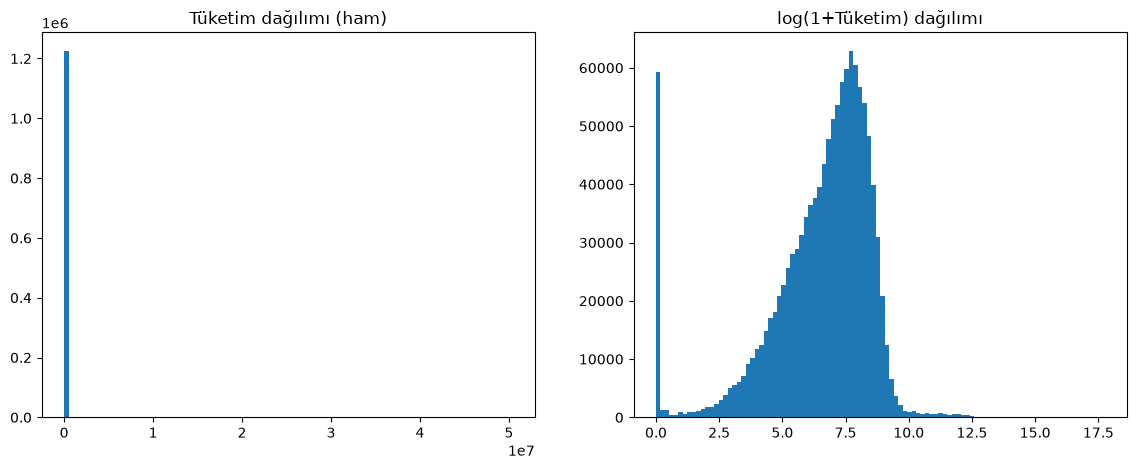

In [34]:
print(train['tuketim'].describe())
print("\nNegatif tuketim sayısı:", (train['tuketim'] < 0).sum())
print("\nSıfır tuketim sayısı:", (train['tuketim'] == 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train['tuketim'], bins=100)
axes[0].set_title('Tüketim dağılımı (ham)')

axes[1].hist(np.log1p(train['tuketim']), bins=100)
axes[1].set_title('log(1+Tüketim) dağılımı')
plt.show()

Aşırı outlier: Ham dağılımda max değer 50 milyon kWh // 75. persentil sadece 2748 iken fazla ve olağandışı bir sıçrama. std (168.782) ortalamadan (3.252) ekstra büyük --> tek tek bakılacak 

Sıfır tüketim kümesi (57.536 satır) log grafikte ana çan eğrisinden ayrı, sıfırda belirgin bir çubuk var. Bu, düşük-tüketimli günlerin doğal kuyruğu değil, ayrı bir kategori gibi duruyor (arıza/sayaç kesintisi ya da gerçekten pasif trafo). Rastgele mi dağılmış yoksa belirli trafolarda mı yoğunlaşmış bakılacak kontrol lazım.

In [43]:
print(train.nlargest(10, 'tuketim')[['tanim','guc','tarih','tuketim','lokasyon']]) # en büyük tüketim değerleri

# Sıfır tüketimin trafo bazında dağılımı
zero_by_trafo = train[train['tuketim'] == 0].groupby('tanim').size().sort_values(ascending=False)
print("\n Sıfır günü olan trafo sayısı:", zero_by_trafo.shape[0], "/ toplam trafo:", train['tanim'].nunique())
print(zero_by_trafo.head(10))

zero_ratio = train.groupby('tanim')['tuketim'].apply(lambda x: (x == 0).mean())
print(f"\nTrafo bazlı sıfır tüketim oranı: \n",zero_ratio.describe())

            tanim    guc      tarih     tuketim                   lokasyon
1106137  75010709  35800 2026-01-26  50403051.0  İZMİR>METROPOL>KARABAĞLAR
790748   75010709  35800 2026-02-10  48324398.4  İZMİR>METROPOL>KARABAĞLAR
837676   75020108  35800 2025-07-12  45631701.0       İZMİR>METROPOL>KONAK
917916   75020108  35800 2025-08-16  45407230.2       İZMİR>METROPOL>KONAK
499994   75010304  35800 2025-12-25  45155642.4       İZMİR>METROPOL>KONAK
581529   75090407  35800 2026-01-30  45028999.8    İZMİR>METROPOL>BAYRAKLI
242303   75020108  35800 2026-02-13  44765323.2       İZMİR>METROPOL>KONAK
943531   75020108  35800 2025-12-17  44303837.4       İZMİR>METROPOL>KONAK
275331   75020108  35800 2025-11-14  43551806.4       İZMİR>METROPOL>KONAK
76186    75020108  35800 2025-11-04  43518355.2       İZMİR>METROPOL>KONAK

 Sıfır günü olan trafo sayısı: 552 / toplam trafo: 5344
tanim
72240114     455
75010705     455
70421989     455
700601469    455
700594714    455
70121764     455
700631202 

75020108 trafosu top-10'da 5 kez tekrarlıyor --> rastgele gürültü değil, sistematik bir sorun var.

guc=35800 kVA olan bir trafo, teorik olarak 24 saat × 35800 kVA maksimum bu civarda enerji tüketebilir. Ama gördüğümüz değerler 50 milyon kWh burada bir sorun var 

Zero tarafındaysa train aralığı (2025-01-01 - 2026-03-31) tam 455 gün bazı trafolarda "455 sıfır günü" görmemiz, o trafoların train'deki tüm süre boyunca hiç aktif olmadığı anlamına geliyor.

In [ ]:
# 1) her zaman sıfır olan trafo sayısı
zero_ratio = train.groupby('tanim')['tuketim'].apply(lambda x: (x == 0).mean())
print("zero_ratio tam istatistik: \n", zero_ratio.describe())

print("\nTamamen (ratio=1.0) sıfır olan trafo sayısı: ", (zero_ratio == 1.0).sum())

always_zero_trafo = zero_ratio[zero_ratio == 1.0].index
print("Bu trafolardan test'te de bulunan:", test[test['tanim'].isin(always_zero_trafo)]['tanim'].nunique())


# 2) imkansız değerleri işaretle
train['max_teorik'] = train['guc'] * 24  # kVA * 24 saat ~ üst sınır (kWh)
train['asiri_oran'] = train['tuketim'] / train['max_teorik']

print("\nasiri_oran > 2 olan satır sayısı (teorik tavanın 2 katından fazla):", (train['asiri_oran'] > 2).sum())
print(train[train['asiri_oran'] > 2].sort_values('asiri_oran', ascending=False)[['tanim','guc','tarih','tuketim','asiri_oran']].head(15))

#298 trafo train'de tamamen sıfır, bunların 234'ü test'te de var. Bu trafolar için güvenle yaklaşık sıfır tahmin edilebilir. 
#444 satır (toplam satırda küçük bir oran) ama fiziksel olarak imkânsız, en kötüsü teorik tavanın 58 katı olan var. 75020108 ve 75010709 gibi birkaç belirli trafoda süregelen bir veri sorunu 

zero_ratio tam istatistik: 
 count    5344.000000
mean        0.067771
std         0.242230
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: tuketim, dtype: float64

Tamamen (ratio=1.0) sıfır olan trafo sayısı: 298
Bu trafolardan test'te de bulunan: 234

asiri_oran > 2 olan satır sayısı (teorik tavanın 2 katından fazla): 444
            tanim    guc      tarih     tuketim  asiri_oran
1106137  75010709  35800 2026-01-26  50403051.0   58.662769
790748   75010709  35800 2026-02-10  48324398.4   56.243480
837676   75020108  35800 2025-07-12  45631701.0   53.109522
917916   75020108  35800 2025-08-16  45407230.2   52.848266
499994   75010304  35800 2025-12-25  45155642.4   52.555450
581529   75090407  35800 2026-01-30  45028999.8   52.408054
779655   75020410  10900 2025-08-09  13677892.2   52.285521
242303   75020108  35800 2026-02-13  44765323.2   52.101168
943531   75020108  35800 2025-12-17  44303837.4   51.564057
275331   75

In [60]:
#Outlierlar nerelerde ve ne kadar yoğun
outliers = train[train['asiri_oran'] > 2]
print("Outlier içeren farklı trafo sayısı:", outliers['tanim'].nunique(), ", toplam:", train['tanim'].nunique())

print("Trafo başına en çok outlier olanlar ve sayısı: \n", outliers['tanim'].value_counts().head(15))



Outlier içeren farklı trafo sayısı: 23 , toplam: 5344
Trafo başına en çok outlier olanlar ve sayısı: 
 tanim
75082213    113
72030261     95
75020110     78
77840445     60
75162401     15
75010202     11
77140232     10
75020108      8
71530512      8
75020101      7
75010313      6
75101912      5
75020402      5
75010708      4
75010709      4
Name: count, dtype: int64


Outlier'ların 444'ünün %78'i sadece 4 trafoda (75082213, 72030261, 75020110, 77840445) yoğunlaşmış, toplamda sadece 23 trafo etkileniyor. Bu, birkaç trafoda süregelen bir ölçüm/veri aktarım sorunu olduğunu gösteriyor (rastgele gürültü değil). Trafo bazlı düzeltme ile Feature Eng. aşamasında 23 trafoyu düzelteceğiz sorun lokalde medyan ve komşu gün ortalaması ile dolduracağız (not edildi yapılacak).